# 01 — VAE Implementation, Step by Step

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement every piece of a VAE for images: encoder, μ/log σ² heads, reparameterization, decoder, ELBO loss
- Train it on MNIST and verify it with **reconstructions**
- **Sample** novel images from the prior and **interpolate** between two real digits in latent space
- Apply the trained pattern to a production task: **anomaly detection** by reconstruction error

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lessons 04 and 12 (the VAE and its latent space) and Course 08 (AIAT 122) — Unit 2, whose convolutional layers this image VAE uses.

**Used later in:** Course 10 — Unit 3, lessons 02-03, which apply and extend this exact architecture.

---

## The Five Pieces of a VAE

1. **Encoder** — a network mapping an image to hidden features.
2. **Two heads** — `mu` and `logvar` layers: each image becomes a *Gaussian* q(z|x), not a point. This is what makes the autoencoder "variational".
3. **Reparameterization** — `z = μ + σ·ε, ε~N(0,1)`: sampling written so gradients flow through μ and σ.
4. **Decoder** — latent vector back to an image; Sigmoid output for [0,1] pixels.
5. **ELBO loss** — per-pixel binary cross-entropy (reconstruction) **+** KL(q(z|x) ‖ N(0,I)) (keeps latent space organized and sampleable).

Find each numbered piece in the code below.

---

## 🌍 Why this lesson exists — the VAE inside Stable Diffusion

The five pieces you are about to build are a shipping component of the most widely downloaded open image generator. Stable Diffusion does **not** run diffusion on pixels: Rombach et al. (2022, arXiv 2112.10752) run it inside a VAE latent space, compressing a 512×512×3 image (786,432 numbers) into a 64×64×4 latent (16,384 numbers) — a **48× reduction**. That compression is the reason text-to-image runs on a consumer GPU instead of a datacentre. The encoder/decoder pair is exactly the architecture below, scaled up and trained on photographs.

**What goes wrong without this:** drop the KL term and you have an ordinary autoencoder — a set of isolated points in latent space. You can compress and reconstruct, but you cannot sample, you cannot interpolate, and there is no continuous space for a diffusion model to operate inside. The KL term is what turns a compressor into a generator.


In [1]:
# WHAT/WHY: build the five VAE pieces and train on MNIST (all ten classes),
# printing the two loss components so you can watch reconstruction and KL
# trade off during training.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16; BATCH = 128; EPOCHS = 6

dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        # Encoder: image → hidden features → two heads (mean, log-variance)
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        # Decoder: latent vector → image (Sigmoid keeps pixels in [0, 1])
        self.dec_fc = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, lv):
        # z = mu + sigma*eps: sampling that gradients can flow through
        return mu + (0.5 * lv).exp() * torch.randn_like(mu)
    def decode(self, z):
        return self.dec_fc(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(z=LATENT)
opt   = optim.Adam(model.parameters(), lr=1e-3)

# ── Training: minimize reconstruction BCE + KL divergence (the ELBO) ──────
for epoch in range(EPOCHS):
    recon_sum = kl_sum = 0.0
    for x, _ in loader:
        recon, mu, lv = model(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
        kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
        loss = recon_loss + kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        recon_sum += recon_loss.item(); kl_sum += kl_loss.item()
    n = len(loader)
    print(f"Epoch {epoch+1}/{EPOCHS} — recon: {recon_sum/n:6.1f}   KL: {kl_sum/n:5.1f}   total: {(recon_sum+kl_sum)/n:6.1f}")
model.eval()
print("\nBoth components per image: reconstruction falls as the decoder improves;")
print("KL stays moderate — the regularizer holding the latent space near N(0, I).")


Epoch 1/6 — recon:  235.8   KL:  11.1   total:  246.9


Epoch 2/6 — recon:  161.0   KL:  13.1   total:  174.0


Epoch 3/6 — recon:  135.2   KL:  16.2   total:  151.3


Epoch 4/6 — recon:  121.5   KL:  18.2   total:  139.6


Epoch 5/6 — recon:  114.2   KL:  19.1   total:  133.3


Epoch 6/6 — recon:  109.5   KL:  19.5   total:  128.9

Both components per image: reconstruction falls as the decoder improves;
KL stays moderate — the regularizer holding the latent space near N(0, I).


## Using the Trained VAE: Reconstruct, Sample, Interpolate

The three standard checks, in one figure each:
- **Reconstruction** — encode + decode unseen test digits (top row real, bottom row reconstruction)
- **Sampling** — decode z ~ N(0, I): novel digits
- **Interpolation** — decode the straight line between two real digits' latent codes


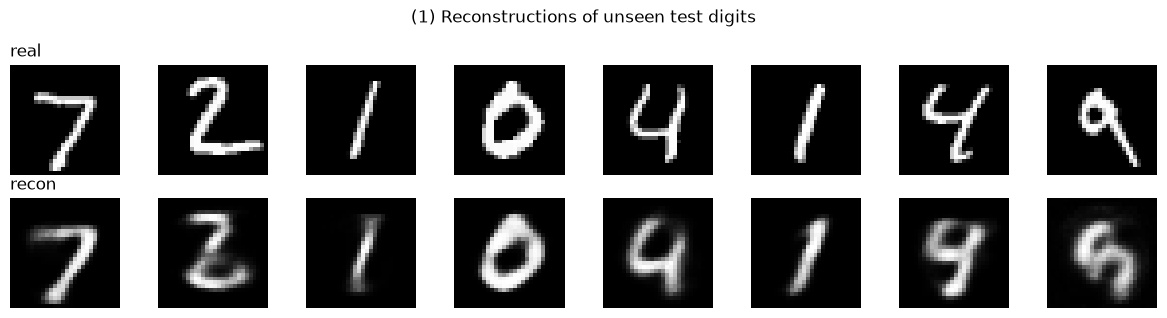

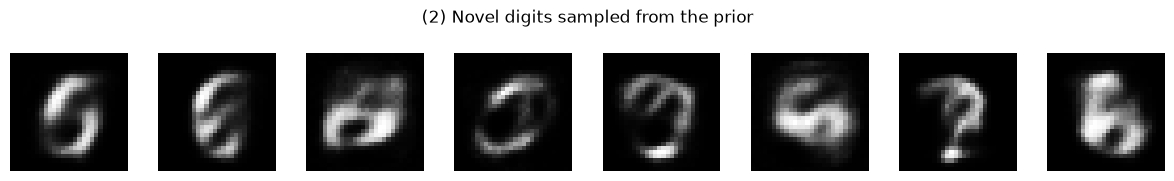

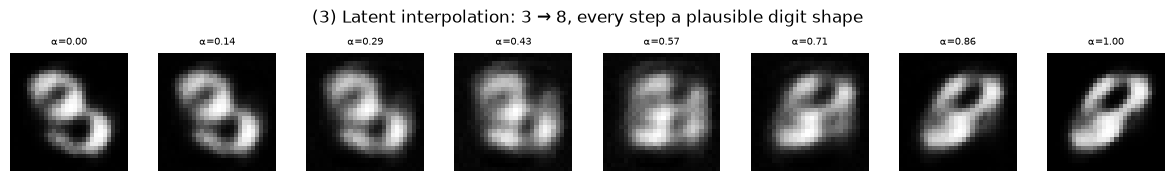

In [2]:
# WHAT/WHY: run the three standard latent-space operations on the model we
# just trained — reconstruction of unseen digits, novel samples from the
# prior, and a latent interpolation between a real 3 and a real 8.
test_ds = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=T.ToTensor())

# ── (1) Reconstructions of unseen test digits ─────────────────────────────
x_test = torch.stack([test_ds[i][0] for i in range(8)])
with torch.no_grad():
    recon, _, _ = model(x_test)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(),  cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_title("real", loc='left'); axes[1, 0].set_title("recon", loc='left')
plt.suptitle("(1) Reconstructions of unseen test digits")
plt.tight_layout(); plt.show()

# ── (2) Novel samples: decode z ~ N(0, I) ─────────────────────────────────
with torch.no_grad():
    samples = model.decode(torch.randn(8, LATENT))
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("(2) Novel digits sampled from the prior")
plt.tight_layout(); plt.show()

# ── (3) Interpolation: straight line between a 3's and an 8's latent code ─
img_a = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 3)
img_b = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8)
with torch.no_grad():
    z_a, _ = model.encode(img_a.unsqueeze(0))   # (1, 1, 28, 28) → latent mean
    z_b, _ = model.encode(img_b.unsqueeze(0))
    steps = torch.linspace(0, 1, 8)
    morphs = torch.cat([model.decode((1 - a) * z_a + a * z_b) for a in steps])
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(morphs[i].squeeze(), cmap='gray'); ax.axis('off')
    ax.set_title(f"α={steps[i]:.2f}", fontsize=7)
plt.suptitle("(3) Latent interpolation: 3 → 8, every step a plausible digit shape")
plt.tight_layout(); plt.show()


## 💬 Discuss

1. Reconstruction fell **235.8 → 109.5** while KL **rose 11.1 → 19.5** over six epochs. Why does the KL term *rise* during training rather than fall? What would you conclude if you saw it fall to near zero while reconstruction kept improving?
2. Stable Diffusion uses its VAE for 48× compression, not for generation — the generating is done by the diffusion model on top. Does that make the KL term more or less important there than here? Argue from what a diffusion model needs from its latent space.
3. Our reconstructions are visibly blurrier than the originals. Name one product where that blur is disqualifying and one where it is irrelevant — and say what property of the product decides it.


## 🌍 Real-World Worked Example — Anomaly Detection with a VAE

**Industry context:**
- **Manufacturing:** VAE-style models flag defective parts on assembly lines
- **Finance:** payment fraud systems score transactions by reconstruction error
- **Healthcare:** models of normal scans flag anomalous MRI images

We retrain the same architecture **only on the digit 0** ("normal" data), then score unseen digits by reconstruction error: 0s reconstruct well, 8s (never seen) reconstruct badly.


Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error — Normal (0): 0.0183  Anomaly (8): 0.0588
Higher error = anomaly flagged (same principle as production fraud detection)


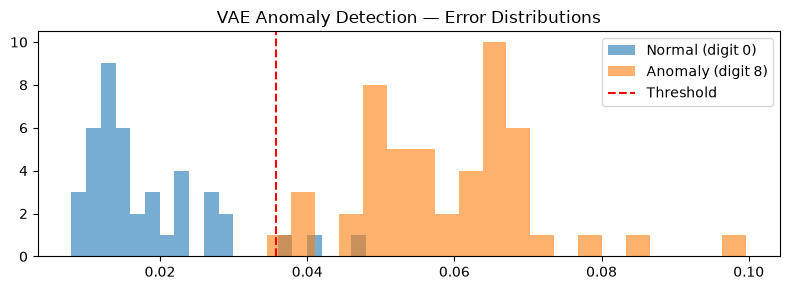

In [3]:
# WHAT/WHY: train a fresh VAE on ONLY digit 0, then use reconstruction error
# as an anomaly score — the unseen class (digit 8) scores much higher, and a
# simple threshold separates the two distributions (see the histogram).
torch.manual_seed(42)

# Train only on digit "0" (the "normal" class)
idx_0 = [i for i, (x, y) in enumerate(dataset) if y == 0][:2000]
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

anomaly_model = VAE()
opt = optim.Adam(anomaly_model.parameters(), lr=1e-3)

for epoch in range(15):
    total = 0
    for x, _ in normal_loader:
        recon, mu, lv = anomaly_model(x)
        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5 * kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")

# ── Score unseen digits: class 0 (seen) vs class 8 (never seen) ───────────
anomaly_model.eval()
samples_0 = torch.stack([test_ds[i][0] for i in range(500)  if test_ds[i][1] == 0][:50])
samples_8 = torch.stack([test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8][:50])

def recon_error(imgs):
    with torch.no_grad():
        recon, _, _ = anomaly_model(imgs)
        return nn.functional.mse_loss(recon, imgs, reduction='none').view(len(imgs), -1).mean(1)

err_0 = recon_error(samples_0).numpy()
err_8 = recon_error(samples_8).numpy()
print(f"\nReconstruction error — Normal (0): {err_0.mean():.4f}  Anomaly (8): {err_8.mean():.4f}")
print("Higher error = anomaly flagged (same principle as production fraud detection)")

# ── Plot the two error distributions with a threshold line ────────────────
plt.figure(figsize=(8, 3))
plt.hist(err_0, bins=20, alpha=0.6, label="Normal (digit 0)")
plt.hist(err_8, bins=20, alpha=0.6, label="Anomaly (digit 8)")
plt.axvline(err_0.mean() + 2 * err_0.std(), color='red', linestyle='--', label="Threshold")
plt.legend(); plt.title("VAE Anomaly Detection — Error Distributions"); plt.tight_layout(); plt.show()


## ⚠️ Where this breaks

**Per-pixel reconstruction loss is an averaging loss, and averaging is blur.** Given several plausible outputs the objective returns their mean. This is a property of the loss, not of training length: more epochs sharpen it slowly and never remove it. If you need sharp, you need a different objective — adversarial (Unit 1) or diffusion (example 04).

**Posterior collapse.** If the decoder is powerful enough, the optimiser can drive KL toward zero, the latent stops carrying information, and the VAE degenerates into an unconditional decoder. Watch the KL component every run: a near-zero KL with a good reconstruction is a broken VAE, not an excellent one.

**The ELBO is a lower bound, so VAE "likelihoods" are not comparable.** You cannot rank a VAE against an exact-likelihood model, and you cannot reliably rank two VAEs with different architectures, because the tightness of the bound differs.

**Cheaper alternative:** if you only ever need compression and reconstruction and will never sample, a plain autoencoder does that job better — no KL term fighting the reconstruction, and a lower reconstruction error for the same capacity.


## 📝 Summary

In this notebook, you implemented and verified the full VAE toolkit on images:
- The **architecture**: encoder → μ/log σ² heads → reparameterized z → decoder
- The **ELBO loss** with both components printed per epoch (reconstruction + KL)
- **Reconstruction, sampling, and interpolation** — all three demonstrated in figures above
- A production application: **anomaly detection**, where the unseen class produced clearly higher reconstruction errors (see printed averages and histogram)

**Next steps:** example 02 applies VAEs further (denoising); example 03 covers conditional VAEs and β-VAE; example 04 introduces diffusion models.


## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(foundational)*
- Doersch (2016) — [Tutorial on Variational Autoencoders](https://arxiv.org/abs/1606.05908)
- Higgins et al. (2017) — [β-VAE](https://openreview.net/forum?id=Sy2fchgcx)
- Vahdat & Kautz (2020) — [NVAE: A Deep Hierarchical Variational Autoencoder](https://arxiv.org/abs/2007.03898) *(how far the pure-VAE recipe scales)*

**State-of-the-Art:** Stable Diffusion runs its diffusion process inside a VAE's latent space — this architecture is a core component of modern image generators.
